# SEE060: Lösning och rättningsmall för Inlämning 3

## Kod

In [1]:
import matplotlib.pyplot as plt
import numpy as np


START = 1990
END = 2300
INITIAL_MASS = 1e10  # kg
EMISSION = 4e8  # kg/year
RESIDENCE_TIME = 100  # year
ZERO_EMISSION_YEAR = 1996


def calc_mass(
    start_year, end_year, dt, initial_mass, emiss, year_zero_emiss, residence_time
):
    t = np.arange(start_year, end_year + dt, dt)
    mass = np.zeros_like(t)
    mass[0] = initial_mass

    for i, t_i in enumerate(t[:-1]):
        if t_i < year_zero_emiss:
            E = emiss
        else:
            E = 0

        mass[i + 1] = mass[i] + dt * (E - mass[i] / residence_time)

    return t, mass

## Fråga 1

### a) Visa att CFC-12 skulle uppnå jämvikt vid $m = 2 \cdot 10^{10}$ kg.

**Svar:**
Vid jämvikt är $\frac{dm}{dt} = 0$, vilket ger (från Ekvation (1)):

$$
0 = E - \frac{m}{\tau} \Rightarrow m = E\tau = 2 \cdot 10^{8} \cdot 100 = 2 \cdot 10^{10}~\text{kg}. 
$$

### b) Detta är högre än massan 1989. Förklara hur detta kan ske?

**Svar:**
Eftersom utsläppstakten är större än nedbrytningstakten (p.g.a. den långa uppehållstiden) kommer massan freoner fortsätta öka.

### a) Skapa en plot som visar hur massan av CFC-12 varierar med tiden

**Svar:**

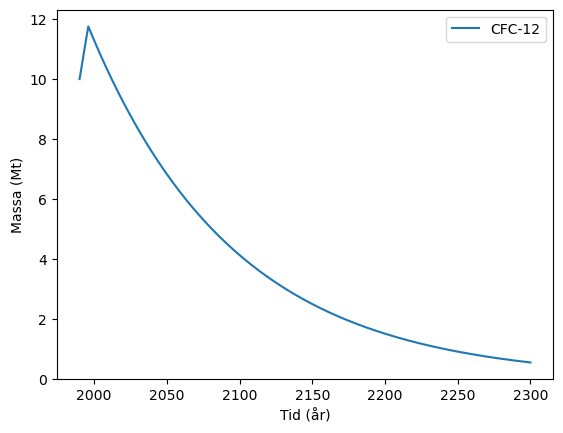

In [2]:
t, m = calc_mass(
    start_year=START,
    end_year=END,
    dt=1,
    initial_mass=INITIAL_MASS,
    emiss=EMISSION,
    year_zero_emiss=ZERO_EMISSION_YEAR,
    residence_time=RESIDENCE_TIME,
)
m = m/1e9  # Mt

fig, ax = plt.subplots()
ax.plot(t, m, label="CFC-12")
ax.set_ylabel("Massa (Mt)")
ax.set_xlabel("Tid (år)")
ax.legend();

### b) Vad är den maximala massan av CFC-12 i atmosfären?

**Svar:** (automatiskt rättat)

In [3]:
print(f"Den maximala massan är {m.max():.2f} Mt.")

Den maximala massan är 11.76 Mt.


### c) Vilket år försvinner ozonhålet?

**Svar:** (automatiskt rättat)

In [4]:
year_ozone_hole = t[m < 7][0]
print(f"Ozonhålet försvinner år {year_ozone_hole}.")

Ozonhålet försvinner år 2048.


### d) Vilket år är CFC-12 borta ur atmosfären?

**Svar:** (automatiskt rättat)

In [5]:
year_cfc_gone = t[m < 1][0]
print(f"CFC-12 är borta ur atmosfären år {year_cfc_gone}.")

CFC-12 är borta ur atmosfären år 2242.


## Fråga 3

### a) Skapa en plot som visar hur massan av CFC-12 varierar med tiden

**Svar:**

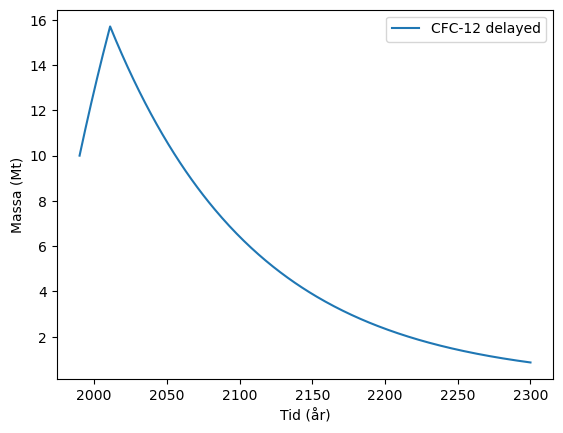

In [6]:
t_delayed, m_delayed = calc_mass(
    start_year=START,
    end_year=END,
    dt=1,
    initial_mass=INITIAL_MASS,
    emiss=EMISSION,
    year_zero_emiss=ZERO_EMISSION_YEAR + 15,
    residence_time=RESIDENCE_TIME,
)
m_delayed = m_delayed/1e9  # Mt

fig, ax = plt.subplots()
ax.plot(t_delayed, m_delayed, label="CFC-12 delayed")
#ax.plot(t, m, 'k--', label="CFC-12 reference")
ax.set_ylabel("Massa (Mt)")
ax.set_xlabel("Tid (år)")
ax.legend();

### b) Vad är den maximala massan av CFC-12 i atmosfären?

**Svar:** (automatiskt rättat)

In [7]:
print(f"Den maximala massan är {m_delayed.max():.2f} Mt.")

Den maximala massan är 15.71 Mt.


### c) Vilket år försvinner ozonhålet?

**Svar:** (automatiskt rättat)

In [8]:
year_ozone_hole_delayed = t_delayed[m_delayed < 7][0]
print(f"Ozonhålet försvinner år {year_ozone_hole_delayed}.")

Ozonhålet försvinner år 2092.


### d) Vilket år är CFC-12 borta ur atmosfären?

**Svar:** (automatiskt rättat)

In [9]:
year_cfc_gone_delayed = t_delayed[m_delayed < 1][0]
print(f"CFC-12 är borta ur atmosfären år {year_cfc_gone_delayed}.")

CFC-12 är borta ur atmosfären år 2286.


### e) Vilken effekt hade en försening av Montrealprotokollet på 15 år fått?

**Svar:**
En 15-årig försening av Montrealprotokollet hade lett till en 44 års fördröjning innan ozonhålet försvinner och CFC-12 är borta ur atmosfären.
Dessutom hade den högsta halten av CFC-12 i atmosfären varit nästan 4 Mt högre (34% högre jämfört med utan fördröjning).

In [10]:
print(f"Difference in peak concentration: {m_delayed.max() - m.max():.2f} Mt.")
print(f"Relative difference in peak concentration: {(m_delayed.max() - m.max())/m.max() * 100:.2f}%.")
print(f"Ozone hole delay: {year_ozone_hole_delayed - year_ozone_hole} years.")
print(f"CFC-12 gone delay: {year_cfc_gone_delayed - year_cfc_gone} years.")

Difference in peak concentration: 3.95 Mt.
Relative difference in peak concentration: 33.62%.
Ozone hole delay: 44 years.
CFC-12 gone delay: 44 years.
